## Purpose
In [linear regression]({{< ref "linear-regression" >}}), we were able to solve for the optimal parameters directly, in closed form, using ordinary least squares. Most models we care about don't afford us that luxury. Gradient descent is the general purpose optimization algorithm that lets us fit a model's parameters iteratively, whenever we can't (or don't want to) solve for them directly. In this article, we'll cover what gradient descent is, the math behind it, and an example implementation, building on the linear regression problem to check our work against a known answer.

## What is Gradient Descent
Imagine you're standing on a hillside in the fog, and you want to get to the bottom of the valley. You can't see the whole landscape, but you can feel which way the ground slopes beneath your feet. A sensible strategy is to take a step in the steepest downhill direction, feel the slope again, take another step, and repeat until the ground feels flat.

That's gradient descent. The "hillside" is our loss function, the "landscape" is the space of possible parameter values, and "downhill" is the direction that decreases the loss the fastest. The slope, mathematically, is the gradient of the loss function with respect to the parameters, and it always points in the direction of steepest *increase* — so we move in the *opposite* direction of the gradient.

Two choices govern how this walk goes:
- **Step size (learning rate)**: how far we move on each step. Too small, and we'll take forever to reach the bottom. Too large, and we might overshoot the valley entirely and end up further away than when we started.
- **Number of steps**: how many times we repeat the process before we call it good enough.

Unlike ordinary least squares for linear regression, gradient descent doesn't require us to solve an equation directly. That makes it far more general: it works for models where no closed-form solution exists at all, such as logistic regression or neural networks, as long as we can compute a gradient.

## Math behind Gradient Descent
We'll reuse the linear regression setup so we can check our answer against a known, closed-form solution. Recall our model is:

$$\hat y = \vec \beta \vec X$$

and our loss function, the sum of squared errors, is:

$$L(D, \vec \beta) = ||X \vec \beta - Y||^2$$

In the linear regression article, we derived the gradient of this loss with respect to $\vec \beta$:

$$\frac{\partial L(D, \vec \beta)}{\partial \vec \beta} = 2X^TX\vec \beta - 2X^TY = 2X^T(X\vec \beta - Y)$$

Last time, we set this gradient to zero and solved for $\vec \beta$ directly. This time, we won't solve it — we'll use it. The gradient tells us the direction of steepest ascent in the loss surface, for our *current* values of $\vec \beta$. So, to reduce the loss, we repeatedly nudge $\vec \beta$ a small step in the opposite direction:

$$\vec \beta_{t+1} = \vec \beta_t - \alpha \frac{\partial L(D, \vec \beta_t)}{\partial \vec \beta_t}$$

Where $\alpha$ is our learning rate, and $t$ indexes the current iteration. Substituting in the gradient we derived above:

$$\vec \beta_{t+1} = \vec \beta_t - 2\alpha X^T(X \vec \beta_t - Y)$$

We start with some initial guess for $\vec \beta_0$ (commonly all zeros), and repeat this update until either the loss stops meaningfully decreasing, or we hit a maximum number of iterations. Because the loss surface for linear regression is convex (a single bowl shape, with one global minimum), this process is guaranteed to converge to the same optimal $\vec \beta$ that OLS finds directly, provided $\alpha$ is small enough.

## Example
For our example, we'll use the classic `tips` dataset: a record of restaurant bills and the tips left by customers. We'll predict the tip amount from the total bill, using gradient descent to fit the same simple linear model from the linear regression article, then verify we land on the same parameters OLS found directly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Here we load the data. `seaborn` ships with a handful of small example datasets, including `tips`, so we can load it directly without needing an external file.

In [2]:
data = sns.load_dataset("tips")
X = data["total_bill"].values
y = data["tip"].values
data.sample(5)

,total_bill,tip,sex,smoker,day,time,size
81,16.66,3.40,Male,No,Thur,Lunch,2
190,15.69,1.50,Male,Yes,Sun,Dinner,2
65,20.08,3.15,Male,No,Sat,Dinner,3
26,13.37,2.00,Male,No,Sat,Dinner,2
239,29.03,5.92,Male,No,Sat,Dinner,3


So, the model we're fitting is:
$$\hat y = \beta_0 + \beta_1 x_0$$
where $x_0$ is the total bill, $\beta_0$ is the intercept, and $\beta_1$ is the coefficient on total bill.

Below, we build a `gradient_descent_linear_regression` class. It mirrors the `linear_regression` class from the earlier article, except instead of an `ols()` method that solves for $\vec \beta$ directly, it has a `fit()` method that iteratively updates $\vec \beta$ using the gradient, exactly as derived above. Along the way, we keep a `loss_history`, so we can see how the loss decreases as training progresses.

In [3]:
class gradient_descent_linear_regression:
    def __init__(self, X, y, learning_rate=5e-6, n_iterations=50000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []
        self.betas = self.fit(X, y)

    def loss(self, X, y, betas):
        y_hat = X @ betas
        return np.sum((y_hat - y) ** 2)

    def gradient(self, X, y, betas):
        y_hat = X @ betas
        return 2 * X.T @ (y_hat - y)

    def fit(self, X, y):
        X = np.array([np.ones(len(X)), X]).T
        betas = np.zeros(X.shape[1])
        for i in range(self.n_iterations):
            betas = betas - self.learning_rate * self.gradient(X, y, betas)
            self.loss_history.append(self.loss(X, y, betas))
        return betas

    def predict(self, X):
        return np.array([np.ones(len(X)), X]).T @ self.betas

Now we create an instance of our `gradient_descent_linear_regression` object and fit it to the data.

In [4]:
gd_lm = gradient_descent_linear_regression(X, y)
gd_lm.betas

array([0.92026961, 0.10502452])

To check our work, let's also solve for $\vec \beta$ directly using the closed-form OLS solution from the linear regression article.

In [5]:
X_with_bias = np.array([np.ones(len(X)), X]).T
betas_ols = np.linalg.pinv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
betas_ols

array([0.92026961, 0.10502452])

The two sets of parameters match, to several decimal places. Gradient descent found its way, one small step at a time, to the same answer OLS solved directly.

### Choosing a learning rate
The learning rate $\alpha$ isn't a free lunch. To see why it matters, let's fit the same model with three different learning rates: one too large, one that works well, and one that's needlessly small.

In [6]:
learning_rates = {"too large (1e-5)": 1e-5, "good (5e-6)": 5e-6, "too small (1e-6)": 1e-6}
comparison_losses = {}

with np.errstate(all="ignore"):
    for label, lr in learning_rates.items():
        model = gradient_descent_linear_regression(X, y, learning_rate=lr, n_iterations=10000)
        comparison_losses[label] = model.loss_history

for label, history in comparison_losses.items():
    print(f"{label}: loss after 10,000 iterations = {history[-1]:.4f}")

too large (1e-5): loss after 10,000 iterations = nan
good (5e-6): loss after 10,000 iterations = 252.7984
too small (1e-6): loss after 10,000 iterations = 259.4613


With too large a learning rate, each step overshoots the bottom of the valley by more than the step before, and the loss explodes rather than shrinks. Too small a learning rate is stable, but after the same 10,000 iterations, it's still far from converged. The "good" learning rate strikes a balance: large enough to make real progress each step, small enough not to overshoot.

In practice, picking $\alpha$ is usually a matter of trial and error, or techniques like a learning rate schedule that shrinks $\alpha$ over time. That's a topic for another day.

Below, we plot the loss over the course of training for our well-tuned model. Notice the characteristic shape: the loss drops quickly at first, then levels off as $\vec \beta$ approaches the bottom of the valley.

Text(0.5, 1.0, 'Gradient Descent Loss over Training')

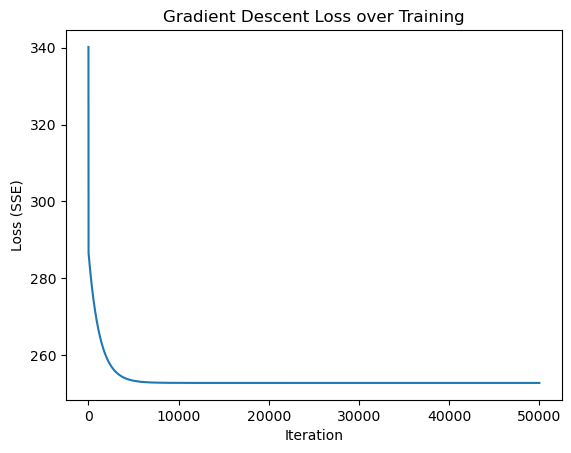

In [7]:
plt.plot(gd_lm.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Loss (SSE)")
plt.title("Gradient Descent Loss over Training")

## Metrics
Since our model converges to the same parameters as OLS, the same metrics we covered in the linear regression article apply here too: mean squared error (MSE), root mean squared error (RMSE), residual sum of squares (RSS), total sum of squares (TSS), and the coefficient of determination ($R^2$).

Let's extend our class with these metrics, computed on the gradient descent fitted parameters.

In [8]:
class gradient_descent_linear_regression:
    def __init__(self, X, y, learning_rate=5e-6, n_iterations=50000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.loss_history = []
        self.betas = self.fit(X, y)
        self.metrics = {}
        self.get_metrics(X, y)

    def loss(self, X, y, betas):
        y_hat = X @ betas
        return np.sum((y_hat - y) ** 2)

    def gradient(self, X, y, betas):
        y_hat = X @ betas
        return 2 * X.T @ (y_hat - y)

    def fit(self, X, y):
        X = np.array([np.ones(len(X)), X]).T
        betas = np.zeros(X.shape[1])
        for i in range(self.n_iterations):
            betas = betas - self.learning_rate * self.gradient(X, y, betas)
            self.loss_history.append(self.loss(X, y, betas))
        return betas

    def predict(self, X):
        return np.array([np.ones(len(X)), X]).T @ self.betas

    def mse(self, X, y):
        y_hat = self.predict(X)
        self.metrics["MSE"] = np.mean((y - y_hat) ** 2)

    def rmse(self):
        self.metrics["RMSE"] = np.sqrt(self.metrics["MSE"])

    def RSS(self, y_hat, y):
        e = y - y_hat
        self.metrics["RSS"] = np.sum(e ** 2)

    def TSS(self, y):
        y_mean = np.mean(y)
        self.metrics["TSS"] = np.sum((y - y_mean) ** 2)

    def r_squared(self, y_hat, y):
        self.metrics["r_squared"] = 1 - (self.metrics["RSS"] / self.metrics["TSS"])

    def get_metrics(self, X, y):
        y_hat = self.predict(X)
        self.mse(X, y)
        self.rmse()
        self.RSS(y_hat, y)
        self.TSS(y)
        self.r_squared(y_hat, y)

In [9]:
gd_lm = gradient_descent_linear_regression(X, y)
gd_lm.metrics

{'MSE': 1.0360194420113773,
 'RMSE': 1.0178504025697377,
 'RSS': 252.78874385077606,
 'TSS': 465.21247704918045,
 'r_squared': 0.45661658635167646}

Notice that the final value of `gd_lm.loss_history[-1]` (the SSE our training loop was actually descending) matches `gd_lm.metrics["RSS"]` above exactly — they're the same quantity, computed on the same fitted parameters, once during training and once as a metric afterward.

We have an RMSE of about `$1.02`, meaning our model's predicted tip is, on average, off by about a dollar. Given tips in this dataset range from about `$1` to `$10`, that's a meaningful error, but not an unreasonable one for a single-feature model.

The $R^2$ value of about 0.46 tells us total bill alone accounts for less than half the variance in tip amount. That tracks with intuition: tipping is also influenced by things like party size, service quality, and personal habit, none of which we've included here.

Finally, let's visualize the fit. The scatter plot shows total bill against tip, with our fitted line overlaid.

Text(0.5, 1.0, 'Predicting Tip from Total Bill')

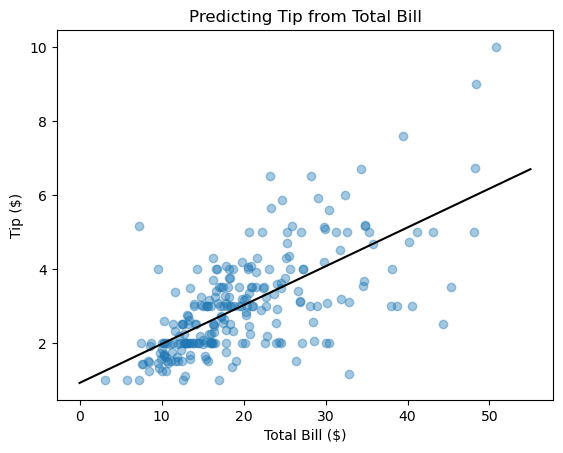

In [10]:
plt.figure()
plt.scatter(X, y, alpha=0.4)
plt.plot([0, 55], [gd_lm.predict([0])[0], gd_lm.predict([55])[0]], "black")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.title("Predicting Tip from Total Bill")

## Conclusion
We covered gradient descent intuitively, as a hillside descent guided by the slope beneath our feet, and mathematically, as an iterative update rule derived from the gradient of a loss function. We verified our from-scratch implementation against the closed-form OLS solution from the linear regression article, and saw firsthand why the choice of learning rate matters.

Gradient descent as we implemented it here uses the *entire* dataset to compute the gradient on every single step, which is often called batch gradient descent. It's a reasonable choice for a dataset with 244 rows, but it doesn't scale well to the massive datasets used to train models like neural networks. Variants like stochastic gradient descent, mini-batch gradient descent, and adaptive methods like Adam address that scaling problem, along with other practical wrinkles like escaping flat regions of the loss surface. Those are all worth their own articles.

Thanks all for reading.